We apply several RNA velocity methods to the HSC dataset.

In [1]:
import numpy as np
import pandas as pd

import cell2fate as c2f
import scanpy as sc
import matplotlib.pyplot as plt

Global seed set to 0


In [2]:
%matplotlib inline

In [3]:
data_outdir = 'processed_data/'
adata_rna_orig = sc.read_loom('data/GSM6403410_3423-MV-2_gex_possorted_bam_ICXFB.loom')
adata_rna_orig.obs_names = [x.split(':')[1][:-1]+'-1' for x in adata_rna_orig.obs_names]
adata_rna_orig.X = adata_rna_orig.layers['spliced'].copy()
adata_rna_orig.layers['raw'] = adata_rna_orig.X.copy()
adata_rna_orig.var_names_make_unique()
adata_rna_filt = sc.read_h5ad(data_outdir+'adata_rna.h5ad')

In [4]:
model_outdir = 'modeling_results/'

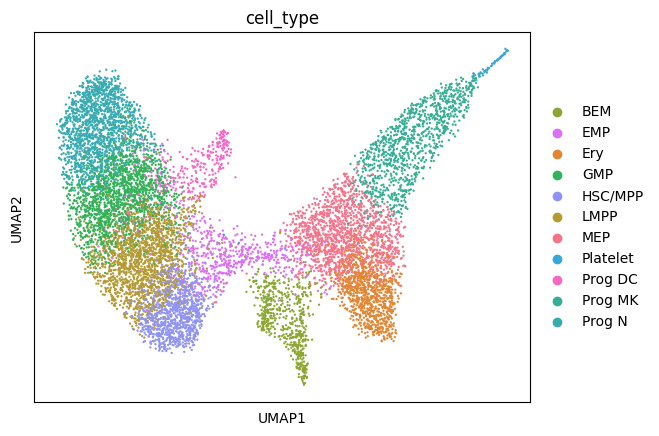

In [5]:
sc.pl.umap(adata_rna_filt, color = 'cell_type')

## Apply Cell2Fate

Apply standard cell2fate pipeline.

In [6]:
adata_rna = adata_rna_orig[adata_rna_filt.obs_names, :].copy()

In [7]:
adata_rna.obs['clusters'] = adata_rna_filt.obs['cell_type']

In [8]:
clusters_to_remove = []
adata = c2f.utils.get_training_data(adata_rna, 
                                    cells_per_cluster = 10**5, 
                                    cluster_column = 'clusters',
                                    remove_clusters = clusters_to_remove,
                                    min_shared_counts = 100, n_var_genes= 1500)

Keeping at most 100000 cells per cluster
Filtered out 29377 genes that are detected 100 counts (shared).
Extracted 1500 highly variable genes.


In [9]:
adata = adata[adata_rna_filt.obs_names,:]

In [10]:
max_modules = c2f.utils.get_max_modules(adata)

Leiden clustering ...
         Falling back to preprocessing with `sc.pp.pca` and default params.
Number of Leiden Clusters: 9
Maximal Number of Modules: 10


In [11]:
c2f.Cell2fate_DynamicalModel.setup_anndata(adata, spliced_label='spliced', unspliced_label='unspliced')

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [12]:
mod = c2f.Cell2fate_DynamicalModel(adata, n_modules = max_modules)#, 
                                   #Tmax_prior={"mean": 500., "sd": 100.})

In [36]:
mod.view_anndata_setup()
mod.train()

Anndata setup with scvi-tools version 0.16.1.

Setup via `Cell2fate_DynamicalModel.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': None,
│   'labels_key': None,
│   'unspliced_label': 'unspliced',
│   'spliced_label': 'spliced',
│   'cluster_label': None
}

     Summary Statistics     
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Summary Stat Key ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│     n_cells      │ 10935 │
│      n_vars      │ 1500  │
│     n_batch      │   1   │
└──────────────────┴───────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│  unspliced   │ adata.layers['unspliced'] │
│   spliced    │  adata.layers['spliced']  │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
└──────────────┴───────────────────────────┘

                     batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_batch'] │     0      │          0          │
└──────────────────────────┴────────────┴─────────────────────┘

GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 500/500: 100%|██████████| 500/500 [11:02<00:00,  1.33s/it, v_num=1, elbo_train=1.85e+7]


In [37]:
import pickle
f = open(model_outdir+'mod.p', 'wb')
pickle.dump(mod, f)
f.close()

In [13]:
import pickle
f = open(model_outdir+'mod.p', 'rb')
mod = pickle.load(f)
f.close()

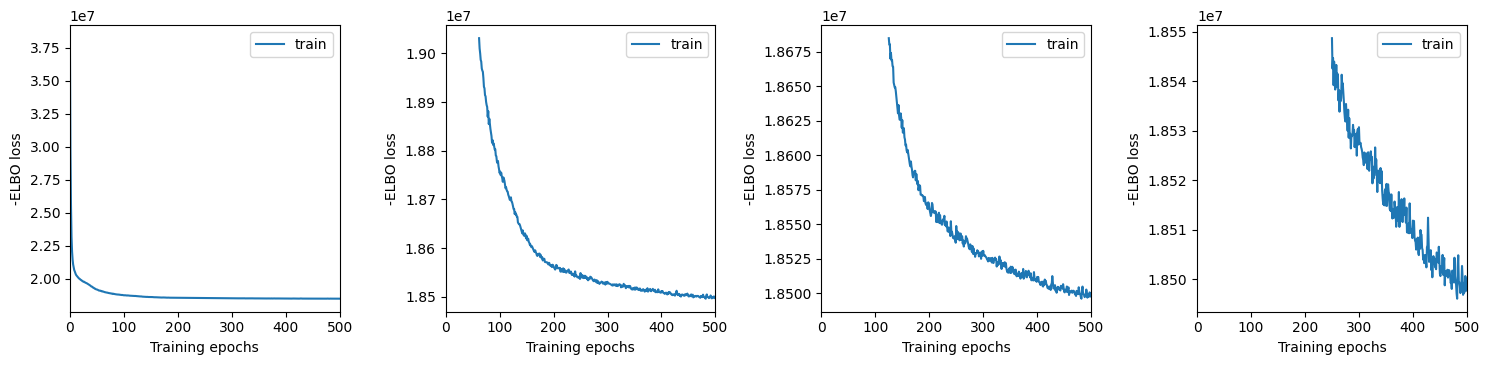

In [14]:
mod.view_history()

In [16]:
adata = mod.export_posterior(adata)

Sampling global variables, sample: 100%|██████████| 29/29 [00:06<00:00,  4.62it/s]


In [17]:
adata = mod.compute_module_summary_statistics(adata)

In [18]:
adata_rna_filt.shape, adata.shape

((10935, 1325), (10935, 1500))

In [19]:
adata = adata[adata_rna_filt.obs_names,:]

In [20]:
adata.obsm['X_umap'] = np.array(adata_rna_filt.obsm['X_umap'])

In [21]:
adata.uns['clusters_colors'] = adata_rna_filt.uns['cell_type_colors']

Computing total RNAvelocity ...


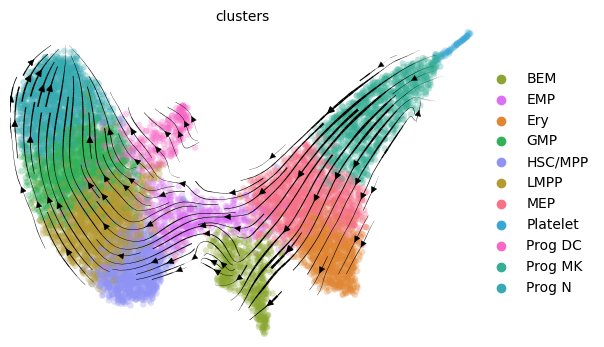

In [22]:
mod.compute_and_plot_total_velocity(adata, 
                                    delete = False,
                                    save = model_outdir+'Cell2Fate_total_velocity_plots.png')

In [23]:
adata.layers['Velocity'] = np.array(adata.layers['Velocity'])

In [24]:
adata.write(model_outdir+'Cell2Fate_result.h5ad')
